In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import CubicSpline
from scipy.signal.windows import gaussian
from scipy.signal import convolve, windows

Q2: Interpolation error
-

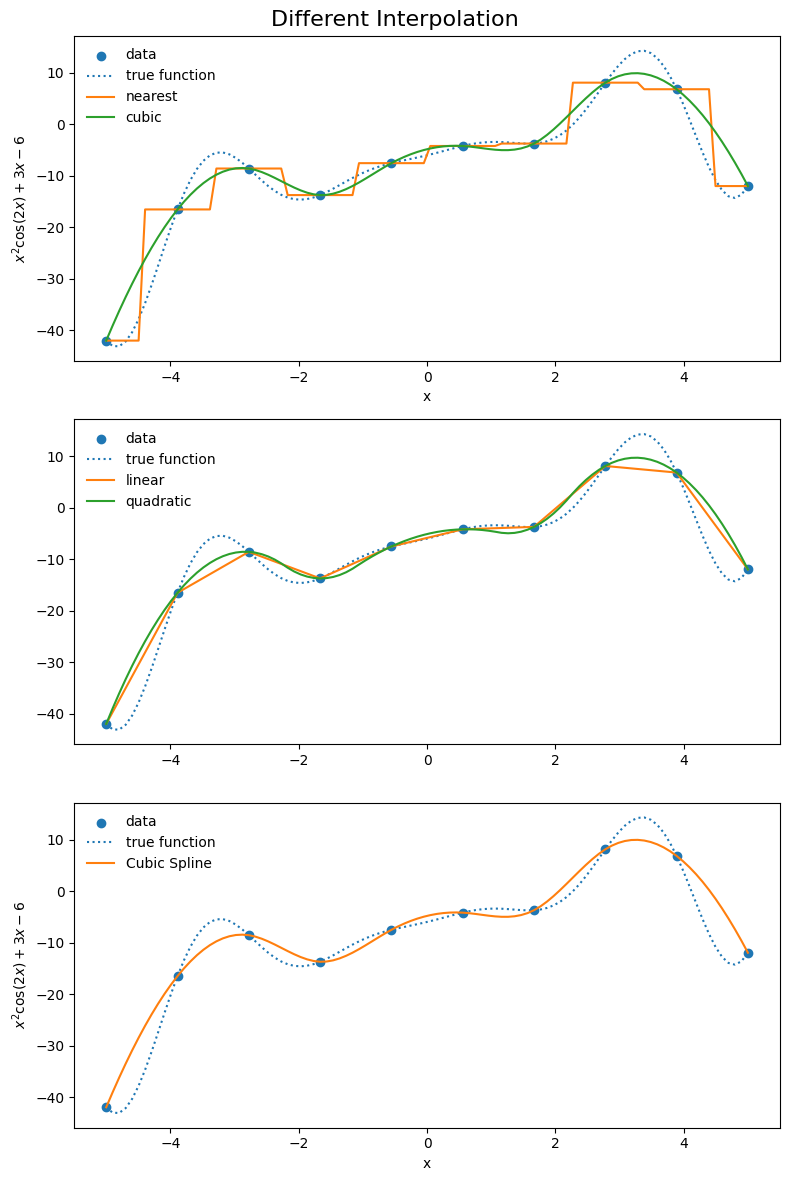

In [5]:
def f_true(x):
    return x**2*np.cos(2*x)+3*x-6


N = 10
x = np.linspace(-5, 5, N)
y = f_true(x)
x_fine = np.linspace(-5, 5, 100)

fig, axs = plt.subplots(3, 1, figsize=(8, 12))
fig.suptitle("Different Interpolation", fontsize=16)

ax = axs[0]
ax.scatter(x, y, label="data")
ax.plot(x_fine, f_true(x_fine), ls=":", label="true function")

f_interp_nearest = interpolate.interp1d(x, y, kind="nearest")
ax.plot(x_fine, f_interp_nearest(x_fine), label="nearest")

f_interp_cubic = interpolate.interp1d(x, y, kind="cubic")
ax.plot(x_fine, f_interp_cubic(x_fine), label="cubic")
ax.set_xlabel("x")
ax.set_ylabel(r"$x^2 \cos(2x) + 3x - 6$")
ax.legend(frameon=False)

ax = axs[1]
ax.scatter(x, y, label="data")
ax.plot(x_fine, f_true(x_fine), ls=":", label="true function")

f_interp_linear = interpolate.interp1d(x, y, kind="linear")
ax.plot(x_fine, f_interp_linear(x_fine), label="linear")

f_interp_quadratic = interpolate.interp1d(x, y, kind="quadratic")
ax.plot(x_fine, f_interp_quadratic(x_fine), label="quadratic")
ax.legend(frameon=False)

ax = axs[2]
ax.scatter(x, y, label="data")
ax.plot(x_fine, f_true(x_fine), ls=":", label="true function")
cs = CubicSpline(x, y)
y_spline = cs(x_fine)
ax.plot(x_fine, y_spline, label="Cubic Spline")
ax.set_xlabel("x")
ax.set_ylabel(r"$x^2 \cos(2x) + 3x - 6$")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [8]:
def errors(y_pred, y_ref):
    diff = y_pred - y_ref
    return {
        "MAE":  np.mean(np.abs(diff)),
        "RMSE": np.sqrt(np.mean(diff**2)),
        "Max":  np.max(np.abs(diff)),
    }


methods = {
    "Nearest":      f_interp_nearest(x_fine),
    "Linear":       f_interp_linear(x_fine),
    "Quadratic":    f_interp_quadratic(x_fine),
    "Cubic":        f_interp_cubic(x_fine),
    "CubicSpline":  cs(x_fine),
}

y_true_fine = f_true(x_fine)
err_table = {name: errors(yp, y_true_fine) for name, yp in methods.items()}

# Print table
print(f"{'Method':<14} {'MAE':>8} {'RMSE':>8} {'Max':>8}")
print("-" * 42)
for name, e in err_table.items():
    print(f"{name:<14} {e['MAE']:>8.4f} {e['RMSE']:>8.4f} {e['Max']:>8.4f}")


Method              MAE     RMSE      Max
------------------------------------------
Nearest          2.9273   4.6429  18.1880
Linear           2.4692   3.5162   7.6226
Quadratic        2.6282   3.7150   9.6458
Cubic            2.5933   3.6135   9.4054
CubicSpline      2.5933   3.6135   9.4054


-----------------
Q7: Noisy signal
--

In [3]:
def fdata(x, L):
    A = L/10.0
    return 2*np.sin(2*np.pi*x/L) + x*(L-x)**2/L**3 * np.cos(x) + \
           5*x*(L-x)/L**2 + A/2 + 0.1*A*np.sin(13*np.pi*x/L)

N = 2048
L = 50.0
x = np.linspace(0, L, N, endpoint=False)
orig = fdata(x, L)
noisy = orig + 0.5*np.random.randn(N)

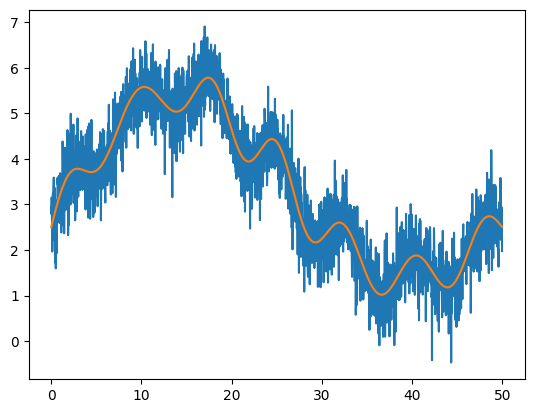

In [4]:
plt.plot(x, noisy)
plt.plot(x, orig)

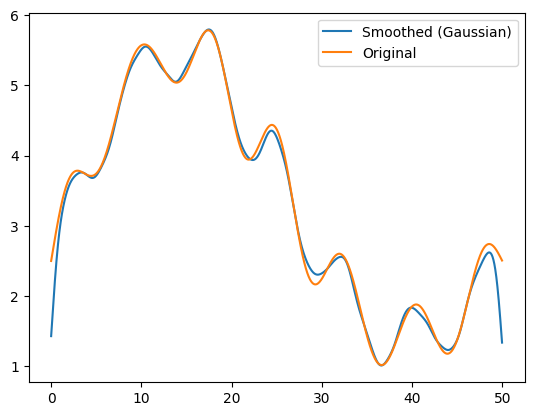

In [13]:
sigma = 25
g = gaussian(N, sigma)
g_norm = g/np.sum(g)
convolution = convolve(noisy, g_norm, mode='same')

plt.plot(x, convolution, label="Smoothed (Gaussian)")
plt.plot(x, orig, label="Original")
plt.legend()